# MOMENTS Goal: Language-Only vs Vision-Only Results

This is a standalone viewer for the current Qwen2 MOMENTS results. It does not modify or depend on `figures_and_results_processing.ipynb`.

The default comparison uses the matched `ap_ig_steps=5` archives: `qwen2-7b-vl-instruct_language_only_nap_ig_l=5` and `qwen2-7b-vl-instruct_vision_only_nap_ig_vl=5`.

## How to read this notebook

This analysis adapts the circuit-comparison logic of Nikankin et al. (2025), *Same Task, Different Circuits*, to the MOMENTS goal task. The paper asks whether a VLM solves an analogous task through one shared circuit or through modality-specific circuits with comparable roles.

For this dataset, the clean input is a video frame plus a transcript-based goal question. The counterfactuals isolate the manipulated modality: language-only changes the transcript while keeping the image fixed; vision-only changes the image while keeping the transcript fixed; both changes both. The text-only `--language_only` runs are controls, not multimodal evidence.

The central questions to answer are:
- Do language and vision conditions retain faithfulness at similar circuit sizes?
- Do their high-attribution nodes occur in the same layers and hooks, or are they largely disjoint?
- If the nodes differ, do the layer-level patterns still suggest similar computational roles?
- Does the multimodal `both` condition require a combined or distinct circuit relative to the isolated perturbations?

A result supports modality-specific mechanisms if the language and vision curves are both meaningful but their top hooks and attribution profiles have low overlap. A result supports shared mechanisms if the same hooks and layers dominate both conditions and their faithfulness curves are similar. Either conclusion requires checking the perturbation validity, row counts, token-length alignment, and baseline behavior first.

In [1]:
print('Paper: https://arxiv.org/abs/2506.09047')
print('Interpretation rule: faithfulness measures circuit sufficiency, while attribution overlap measures circuit similarity; neither alone proves a mechanism.')

Paper: https://arxiv.org/abs/2506.09047
Interpretation rule: faithfulness measures circuit sufficiency, while attribution overlap measures circuit similarity; neither alone proves a mechanism.


In [2]:
from pathlib import Path
import re
import torch
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline

# Support launching Jupyter from either this nested repo or the thesis repo root.
if (Path('data/moments_goal/results')).exists():
    REPO_ROOT = Path('.')
elif (Path('reproducing_code/vlm-circuits-analysis/data/moments_goal/results')).exists():
    REPO_ROOT = Path('reproducing_code/vlm-circuits-analysis')
else:
    REPO_ROOT = Path('.')
RESULTS_ROOT = REPO_ROOT / 'data/moments_goal/results'
LANGUAGE_DIR = RESULTS_ROOT / 'qwen2-7b-vl-instruct_language_only_nap_ig_l=5'
VISION_DIR = RESULTS_ROOT / 'qwen2-7b-vl-instruct_vision_only_nap_ig_vl=5'
BOTH_DIR = RESULTS_ROOT / 'qwen2-7b-vl-instruct'
OUTPUT_DIR = REPO_ROOT / 'figures/moments_language_vision_results'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS = {
    'language_only': {
        'label': 'Language only',
        'faithfulness': LANGUAGE_DIR / 'faithfulness_LD_l_node_circuit.pt',
        'scores': LANGUAGE_DIR / 'node_scores/nap_ig_l_ig=5_metric=LD.pt',
    },
    'vision_only': {
        'label': 'Vision only',
        'faithfulness': VISION_DIR / 'faithfulness_LD_vl_node_circuit.pt',
        'scores': VISION_DIR / 'node_scores/nap_ig_vl_ig=5_metric=LD.pt',
    },
    'both_multimodal': {
        'label': 'Both (multimodal)',
        'faithfulness': BOTH_DIR / 'faithfulness_LD_vl_node_circuit.pt',
        'scores': BOTH_DIR / 'node_scores/nap_ig_vl_ig=5_metric=LD.pt',
    },
    'both_text_only': {
        'label': 'Both (text only)',
        'faithfulness': BOTH_DIR / 'faithfulness_LD_l_node_circuit.pt',
        'scores': BOTH_DIR / 'node_scores/nap_ig_l_ig=5_metric=LD.pt',
    },
}

for name, result in RESULTS.items():
    print(name)
    print('  faithfulness:', result['faithfulness'], result['faithfulness'].exists())
    print('  scores:', result['scores'], result['scores'].exists())

def faithfulness_is_complete(path):
    if not path.exists():
        return False
    _, _, completed = torch.load(path, weights_only=True)
    # Only the diagonal stores completion status for each requested checkpoint.
    return bool(completed.detach().cpu().bool().diag().all().item())

AVAILABLE_RESULTS = {
    name: result for name, result in RESULTS.items()
    if result['faithfulness'].exists()
    and result['scores'].exists()
    and faithfulness_is_complete(result['faithfulness'])
}
print('Available complete conditions:', list(AVAILABLE_RESULTS))
print('Incomplete conditions are intentionally excluded until all faithfulness checkpoints are complete.')
if not AVAILABLE_RESULTS:
    raise FileNotFoundError(
        f'No complete result sets were found. Copy the completed .pt files from Snellius into {RESULTS_ROOT}/qwen2-7b-vl-instruct* and rerun this cell.'
    )

language_only
  faithfulness: data/moments_goal/results/qwen2-7b-vl-instruct_language_only_nap_ig_l=5/faithfulness_LD_l_node_circuit.pt True
  scores: data/moments_goal/results/qwen2-7b-vl-instruct_language_only_nap_ig_l=5/node_scores/nap_ig_l_ig=5_metric=LD.pt True
vision_only
  faithfulness: data/moments_goal/results/qwen2-7b-vl-instruct_vision_only_nap_ig_vl=5/faithfulness_LD_vl_node_circuit.pt True
  scores: data/moments_goal/results/qwen2-7b-vl-instruct_vision_only_nap_ig_vl=5/node_scores/nap_ig_vl_ig=5_metric=LD.pt True
both_multimodal
  faithfulness: data/moments_goal/results/qwen2-7b-vl-instruct/faithfulness_LD_vl_node_circuit.pt True
  scores: data/moments_goal/results/qwen2-7b-vl-instruct/node_scores/nap_ig_vl_ig=5_metric=LD.pt True
both_text_only
  faithfulness: data/moments_goal/results/qwen2-7b-vl-instruct/faithfulness_LD_l_node_circuit.pt True
  scores: data/moments_goal/results/qwen2-7b-vl-instruct/node_scores/nap_ig_l_ig=5_metric=LD.pt True
Available complete conditions

## Faithfulness curves

Faithfulness is the normalized LD circuit-ablation score, not a probability. Values below zero or above one can occur.

In [3]:
faithfulness_tables = {}
for name, result in AVAILABLE_RESULTS.items():
    percentages, values, completed = torch.load(result['faithfulness'], weights_only=True)
    percentages = list(percentages)
    values = values.detach().float().cpu().diag().tolist()
    completed = completed.detach().cpu().diag().tolist()
    faithfulness_tables[name] = pd.DataFrame({
        'condition': result['label'],
        'circuit_fraction': percentages,
        'circuit_percent': [100 * x for x in percentages],
        'faithfulness_LD': values,
        'completed': completed,
    })
if not faithfulness_tables:
    raise RuntimeError('No faithfulness tables were loaded; inspect AVAILABLE_RESULTS above.')
faithfulness = pd.concat(faithfulness_tables.values(), ignore_index=True)
display(faithfulness)

,condition,circuit_fraction,circuit_percent,faithfulness_LD,completed
0,Language only,0.000,0.000000,0.000000,True
1,Language only,0.001,0.100000,-0.004969,True
2,Language only,0.005,0.500000,0.005925,True
3,Language only,0.010,1.000000,-0.024753,True
4,Language only,0.020,2.000000,0.004952,True
...,...,...,...,...,...
103,Both (text only),0.200,20.000000,-0.288830,True
104,Both (text only),0.300,30.000001,-2.866316,True
105,Both (text only),0.500,50.000000,0.431082,True
106,Both (text only),0.700,69.999999,0.433128,True


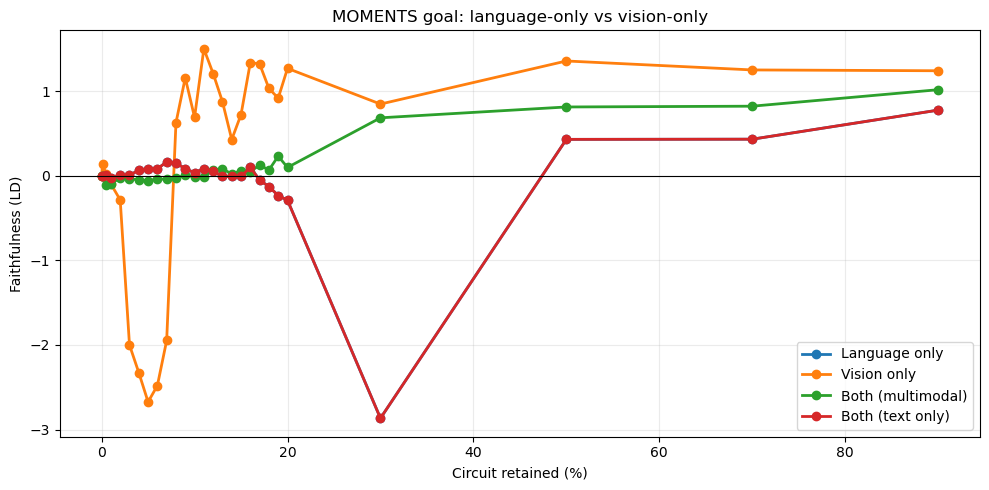

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, table in faithfulness_tables.items():
    ax.plot(table['circuit_percent'], table['faithfulness_LD'], marker='o', linewidth=2, label=RESULTS[name]['label'])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Circuit retained (%)')
ax.set_ylabel('Faithfulness (LD)')
ax.set_title('MOMENTS goal: language-only vs vision-only')
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'faithfulness_language_vs_vision.png', dpi=200, bbox_inches='tight')
plt.show()

## What to look for in the faithfulness plot

The x-axis is the percentage of nodes retained in the circuit; the y-axis is normalized LD faithfulness. A curve that rises quickly indicates that a small discovered circuit is sufficient for the evaluation condition. A curve that stays near zero or is unstable means that the discovered attribution scores do not identify a compact, reliably sufficient circuit under this evaluation.

Compare the language-only and vision-only curves descriptively, not by assuming that the highest point must be the answer. Similar curve shapes would suggest comparable circuit sufficiency; different shapes would suggest modality-dependent circuit organization or different perturbation difficulty. Negative or greater-than-one values are possible for this normalized metric and should be reported as diagnostic behavior, not as probabilities.

For the `both` conditions, ask whether the multimodal curve resembles one isolated modality, combines both patterns, or behaves differently. This is evidence about the circuit used by the model for this counterfactual, not direct evidence that the model understood the transcript semantically.

## Attribution by layer

The saved node scores are position-specific. This summarizes each hook by maximum and mean absolute attribution, grouped by transformer layer.

In [5]:
def attribution_table(scores_path):
    scores = torch.load(scores_path, weights_only=True)
    rows = []
    for hook, tensor in scores.items():
        tensor = tensor.detach().float().cpu().abs()
        match = re.search(r'blocks\.(\d+)\.', str(hook))
        if match is None:
            continue
        rows.append({
            'hook': str(hook),
            'layer': int(match.group(1)),
            'max_abs_score': float(tensor.max()),
            'mean_abs_score': float(tensor.mean()),
            'num_values': tensor.numel(),
        })
    return pd.DataFrame(rows).sort_values(['layer', 'hook']).reset_index(drop=True)

attributions = {name: attribution_table(result['scores']) for name, result in AVAILABLE_RESULTS.items()}
for name, table in attributions.items():
    print(RESULTS[name]['label'])
    display(table.sort_values('max_abs_score', ascending=False).head(15))

Language only


,hook,layer,max_abs_score,mean_abs_score,num_values
3,blocks.1.mlp.hook_post,1,0.015577,0.000002,1970176
55,blocks.27.mlp.hook_post,27,0.013509,0.000002,1970176
5,blocks.2.mlp.hook_post,2,0.007471,0.000003,1970176
1,blocks.0.mlp.hook_post,0,0.004682,0.000005,1970176
35,blocks.17.mlp.hook_post,17,0.004423,0.000011,1970176
19,blocks.9.mlp.hook_post,9,0.004003,0.000012,1970176
45,blocks.22.mlp.hook_post,22,0.003468,0.000003,1970176
9,blocks.4.mlp.hook_post,4,0.003451,0.000007,1970176
21,blocks.10.mlp.hook_post,10,0.003354,0.000015,1970176
39,blocks.19.mlp.hook_post,19,0.003212,0.000005,1970176


Vision only


,hook,layer,max_abs_score,mean_abs_score,num_values
0,blocks.0.attn.hook_z,0,0.004155,2.065016e-06,738304
19,blocks.9.mlp.hook_post,9,0.003367,4.552091e-06,3902464
55,blocks.27.mlp.hook_post,27,0.003286,2.111609e-07,3902464
5,blocks.2.mlp.hook_post,2,0.003055,8.479871e-07,3902464
9,blocks.4.mlp.hook_post,4,0.002402,1.810549e-06,3902464
23,blocks.11.mlp.hook_post,11,0.002097,5.383941e-06,3902464
7,blocks.3.mlp.hook_post,3,0.001868,1.194673e-06,3902464
3,blocks.1.mlp.hook_post,1,0.001749,6.895742e-07,3902464
13,blocks.6.mlp.hook_post,6,0.001703,4.267790e-06,3902464
2,blocks.1.attn.hook_z,1,0.001585,2.152297e-06,738304


Both (multimodal)


,hook,layer,max_abs_score,mean_abs_score,num_values
55,blocks.27.mlp.hook_post,27,0.010439,6.171664e-07,3902464
0,blocks.0.attn.hook_z,0,0.007952,9.823902e-06,738304
3,blocks.1.mlp.hook_post,1,0.007426,1.525096e-06,3902464
19,blocks.9.mlp.hook_post,9,0.006212,1.067907e-05,3902464
7,blocks.3.mlp.hook_post,3,0.005193,3.698847e-06,3902464
45,blocks.22.mlp.hook_post,22,0.004632,1.249491e-06,3902464
9,blocks.4.mlp.hook_post,4,0.004568,5.476330e-06,3902464
35,blocks.17.mlp.hook_post,17,0.004505,6.578179e-06,3902464
5,blocks.2.mlp.hook_post,2,0.004386,2.452490e-06,3902464
1,blocks.0.mlp.hook_post,0,0.004097,3.887377e-06,3902464


Both (text only)


,hook,layer,max_abs_score,mean_abs_score,num_values
3,blocks.1.mlp.hook_post,1,0.015577,0.000002,1970176
55,blocks.27.mlp.hook_post,27,0.013509,0.000002,1970176
5,blocks.2.mlp.hook_post,2,0.007471,0.000003,1970176
1,blocks.0.mlp.hook_post,0,0.004682,0.000005,1970176
35,blocks.17.mlp.hook_post,17,0.004423,0.000011,1970176
19,blocks.9.mlp.hook_post,9,0.004003,0.000012,1970176
45,blocks.22.mlp.hook_post,22,0.003468,0.000003,1970176
9,blocks.4.mlp.hook_post,4,0.003451,0.000007,1970176
21,blocks.10.mlp.hook_post,10,0.003354,0.000015,1970176
39,blocks.19.mlp.hook_post,19,0.003212,0.000005,1970176


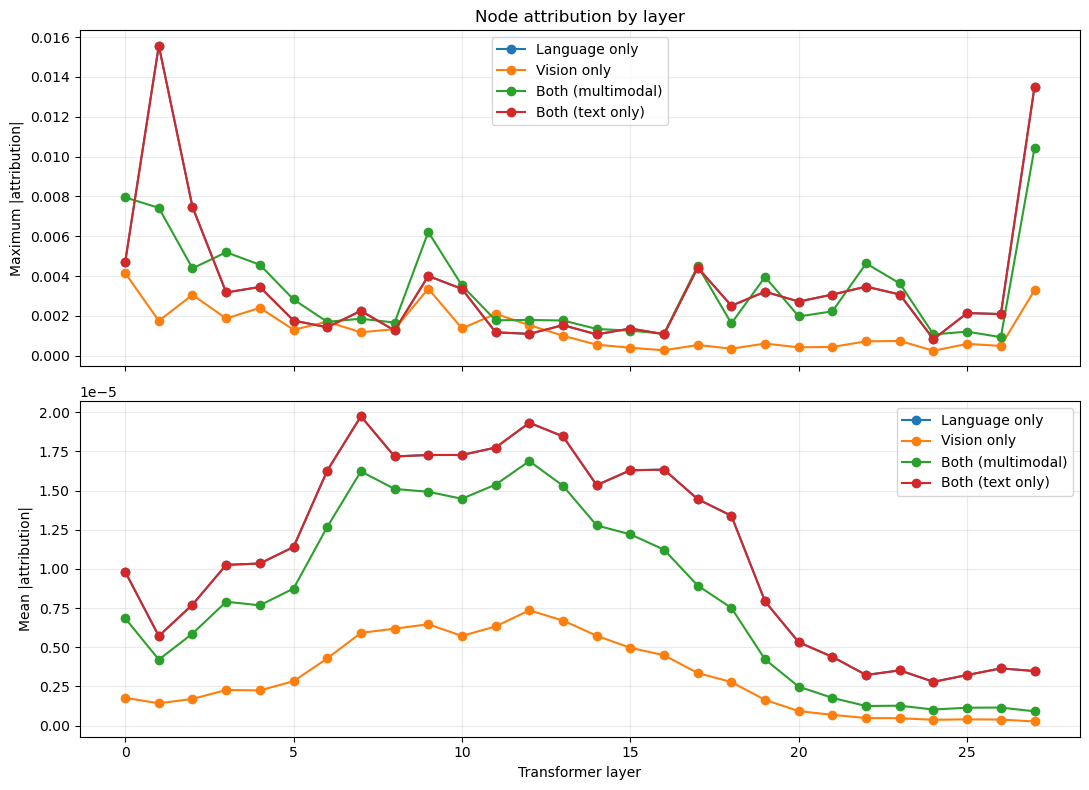

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
for name, table in attributions.items():
    by_layer = table.groupby('layer', as_index=False).agg(max_abs_score=('max_abs_score', 'max'), mean_abs_score=('mean_abs_score', 'mean'))
    axes[0].plot(by_layer['layer'], by_layer['max_abs_score'], marker='o', label=RESULTS[name]['label'])
    axes[1].plot(by_layer['layer'], by_layer['mean_abs_score'], marker='o', label=RESULTS[name]['label'])
axes[0].set_ylabel('Maximum |attribution|')
axes[1].set_ylabel('Mean |attribution|')
axes[1].set_xlabel('Transformer layer')
axes[0].set_title('Node attribution by layer')
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'attribution_by_layer_language_vs_vision.png', dpi=200, bbox_inches='tight')
plt.show()

## What to look for in the layer plot

The maximum curve highlights possible specialized nodes, while the mean curve is less sensitive to one extreme feature. If language and vision peaks occur in different layers or hooks, that is consistent with modality-specific processing. If they peak in similar layers but use different hooks, that may indicate similar computational stages with modality-specific representations. If both maxima and means align, that is stronger evidence for shared organization, although it still does not establish functional equivalence.

The paper emphasizes that modality-specific circuits can be largely disjoint while implementing analogous functions. Therefore, do not treat low hook overlap as failure: inspect whether the layer-level profiles and faithfulness behavior remain functionally similar. The next analysis step for a strong claim is an explicit top-k overlap/Jaccard or intersection analysis, ideally with a random-overlap baseline.

## Top nodes and exports

Use these tables to inspect the hooks contributing most strongly in each condition. A high maximum alone is not evidence of a stable circuit; compare maxima, means, and overlap between conditions.

In [7]:
top_nodes = []
for name, table in attributions.items():
    top = table.sort_values('max_abs_score', ascending=False).head(20).copy()
    top.insert(0, 'condition', RESULTS[name]['label'])
    top_nodes.append(top)
top_nodes = pd.concat(top_nodes, ignore_index=True)
display(top_nodes)

faithfulness.to_csv(OUTPUT_DIR / 'faithfulness_language_vs_vision.csv', index=False)
top_nodes.to_csv(OUTPUT_DIR / 'top_nodes_language_vs_vision.csv', index=False)
print('Saved outputs to:', OUTPUT_DIR.resolve())

,condition,hook,layer,max_abs_score,mean_abs_score,num_values
0,Language only,blocks.1.mlp.hook_post,1,0.015577,0.000002,1970176
1,Language only,blocks.27.mlp.hook_post,27,0.013509,0.000002,1970176
2,Language only,blocks.2.mlp.hook_post,2,0.007471,0.000003,1970176
3,Language only,blocks.0.mlp.hook_post,0,0.004682,0.000005,1970176
4,Language only,blocks.17.mlp.hook_post,17,0.004423,0.000011,1970176
...,...,...,...,...,...,...
75,Both (text only),blocks.18.mlp.hook_post,18,0.002508,0.000007,1970176
76,Both (text only),blocks.7.mlp.hook_post,7,0.002252,0.000015,1970176
77,Both (text only),blocks.25.mlp.hook_post,25,0.002140,0.000002,1970176
78,Both (text only),blocks.26.mlp.hook_post,26,0.002089,0.000002,1970176


Saved outputs to: /gpfs/home5/eboccaletti/reproducing_code/vlm-circuits-analysis/figures/moments_language_vision_results
